             participant_id                 timestamp  \
0     не было прогресс бара     не было прогресс бара   
1                   не было                         5   
2          сначала не понял                что делать   
3  2026-04-20T08:42:12.356Z                   не было   
4                         7  2026-04-20T07:48:04.001Z   

        q1_progress_bar_control q2_progress_bar_orientation  \
0               не делал ошибки                           5   
1                            10                 тёмный блок   
2   пришлось вчитываться в сайт                           6   
3                       не было                     не было   
4         не было прогресс бара       не было прогресс бара   

  q3_errors_influence q4_errors_annoyance                   q5_404_rating  \
0                   8      странный шрифт                       кинотеатр   
1             крестик         надпись 404                             Нет   
2                   9       Рваная плёнка    та

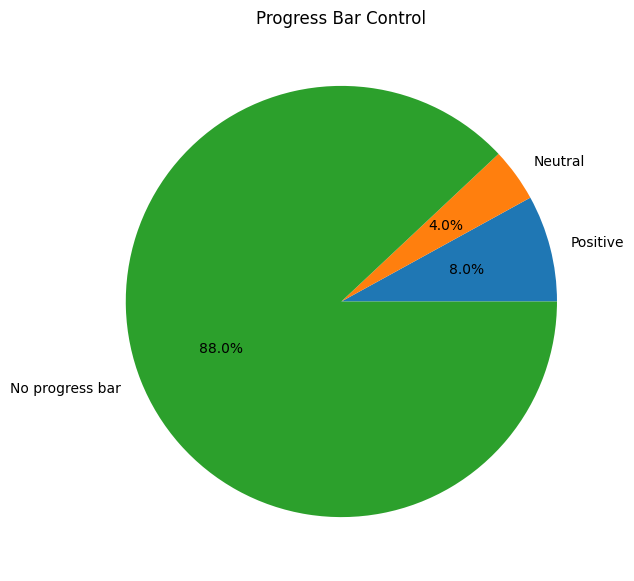

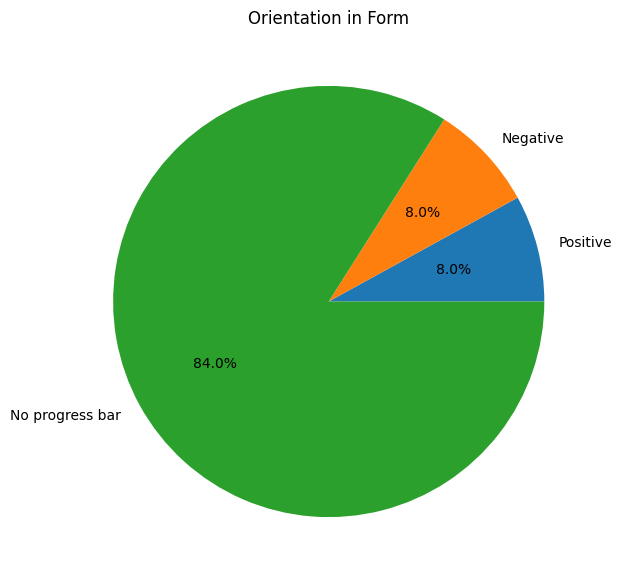

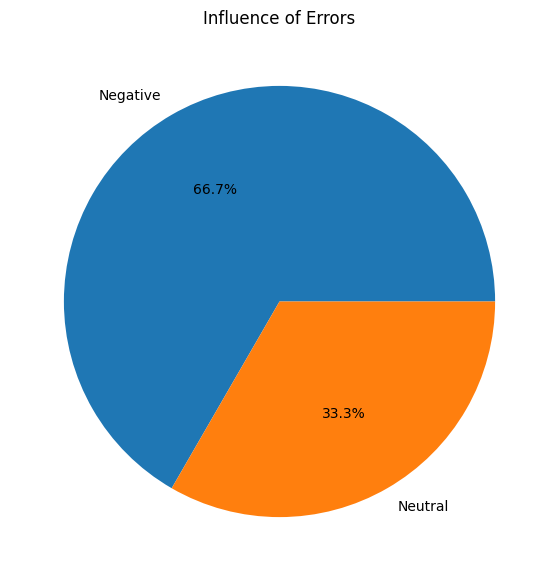

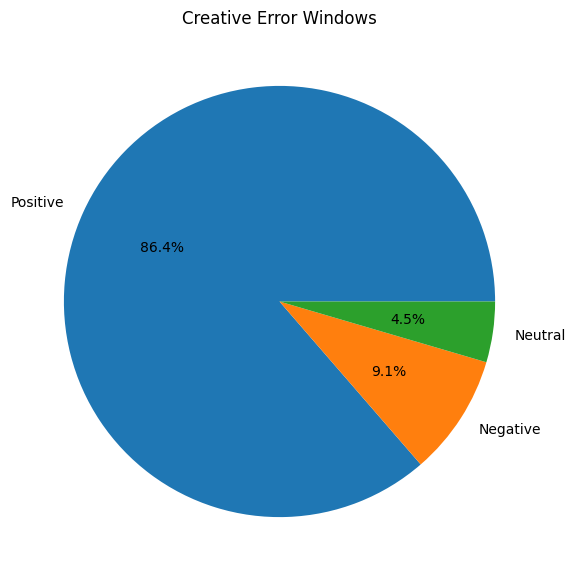

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# =====================================================
# ЗАГРУЗКА АНКЕТ
# =====================================================

files = glob.glob(
    '/content/drive/MyDrive/survey/*.csv'
)

all_dfs = []

for file in files:
    temp_df = pd.read_csv(file)
    all_dfs.append(temp_df)

# объединение
df = pd.concat(
    all_dfs,
    ignore_index=True
)

print(df.head())

# =====================================================
# СЛОВАРИ
# =====================================================

positive_words = [
    'круто',
    'приятно',
    'кайф',
    'здорово',
    'удобно',
    'понятно',
    'помогло',
    'лучше',
    'классно',
    'интересно',
    'оригинально',
    'позитивно',
    'комфорт',
    'отлично',
    'спокойствие',
    'правильно'
]

negative_words = [
    'раздражать',
    'не помогло',
    'бесполезны',
    'ерунда',
    'сомнительно',
    'мешали',
    'ступор',
    'грустным'
]

neutral_words = [
    'не помню',
    'не заметил',
    'не заметила',
    'не запомнил',
    'не запомнила',
    'ничего необычного',
    'сплошной фон'
]

no_progress_words = [
    'не было'
]

# =====================================================
# ФУНКЦИЯ АНАЛИЗА
# =====================================================

def analyze_answers(series, check_progress=False):
    positive = 0
    negative = 0
    neutral = 0
    no_progress = 0

    for answer in series.dropna():
        answer = str(answer).lower()

        # =============================================
        # ПРОВЕРКА "НЕ БЫЛО"
        # =============================================
        if check_progress:
            found = False
            for word in no_progress_words:
                if word in answer:
                    no_progress += 1
                    found = True
                    break
            if found:
                continue

        # =============================================
        # POSITIVE
        # =============================================
        found = False
        for word in positive_words:
            if word in answer:
                positive += 1
                found = True
                break
        if found:
            continue

        # =============================================
        # NEGATIVE
        # =============================================
        for word in negative_words:
            if word in answer:
                negative += 1
                found = True
                break
        if found:
            continue

        # =============================================
        # NEUTRAL
        # =============================================
        for word in neutral_words:
            if word in answer:
                neutral += 1
                found = True
                break

    return {
        'Positive': positive,
        'Negative': negative,
        'Neutral': neutral,
        'No progress bar': no_progress
    }

# =====================================================
# АНАЛИЗ ВОПРОСОВ — ИСПРАВЛЕННЫЕ НАЗВАНИЯ СТОЛБЦОВ
# =====================================================

q1_result = analyze_answers(
    df['q1_progress_bar_control'],    # вместо Q1
    check_progress=True
)

q2_result = analyze_answers(
    df['q2_progress_bar_orientation'], # вместо Q2
    check_progress=True
)

q3_result = analyze_answers(
    df['q3_errors_influence']         # вместо Q3
)

q8_result = analyze_answers(
    df['q8_creative_errors']          # вместо Q8
)

# =====================================================
# PIE CHART
# =====================================================

def draw_pie(results, title):
    labels = []
    sizes = []

    for key, value in results.items():
        if value > 0:
            labels.append(key)
            sizes.append(value)

    plt.figure(figsize=(7, 7))
    plt.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%'
    )
    plt.title(title)
    plt.show()

# =====================================================
# ГРАФИКИ
# =====================================================

draw_pie(
    q1_result,
    'Progress Bar Control'
)

draw_pie(
    q2_result,
    'Orientation in Form'
)

draw_pie(
    q3_result,
    'Influence of Errors'
)

draw_pie(
    q8_result,
    'Creative Error Windows'
)